In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io.fits import Header
from reproject import reproject_exact
from astropy.nddata import NDData



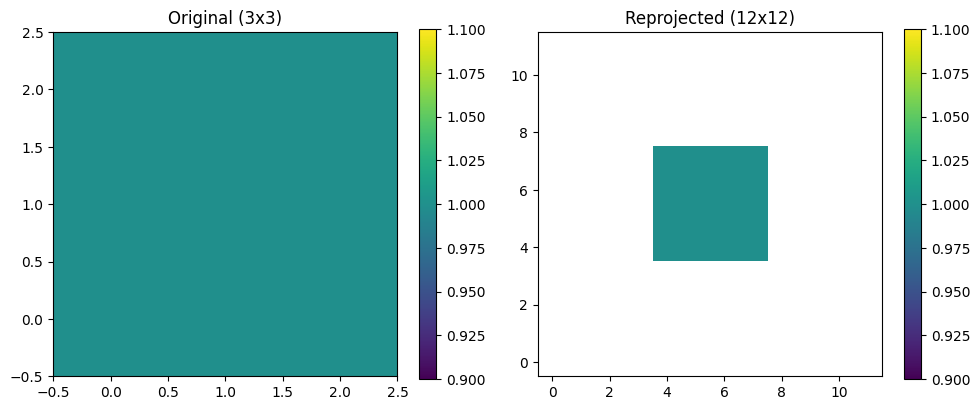

In [5]:
def create_simple_wcs(naxis1, naxis2, crval1=0, crval2=0, cdelt=1.0):
    """
    Create a simple WCS with square pixels.
    """
    header = Header()
    header['NAXIS'] = 2
    header['NAXIS1'] = naxis1
    header['NAXIS2'] = naxis2
    header['CTYPE1'] = 'RA---TAN'
    header['CTYPE2'] = 'DEC--TAN'
    header['CRPIX1'] = naxis1 / 2
    header['CRPIX2'] = naxis2 / 2
    header['CRVAL1'] = crval1
    header['CRVAL2'] = crval2
    header['CDELT1'] = -cdelt
    header['CDELT2'] = cdelt
    header['CUNIT1'] = 'deg'
    header['CUNIT2'] = 'deg'
    return WCS(header)

def test_reproject_exact():
    # Step 1: Create original data and WCS
    data = np.ones((3, 3))
    input_wcs = create_simple_wcs(3, 3)

    # Step 2: Create target header and WCS for 6x6 image
    output_wcs = create_simple_wcs(12, 12)
    output_shape = (12,12)

    # Step 3: Reproject
    reprojected_data, _ = reproject_exact((data, input_wcs), output_wcs, shape_out=output_shape)

    # Step 4: Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im1 = axes[0].imshow(data, origin='lower', cmap='viridis')
    axes[0].set_title('Original (3x3)')
    plt.colorbar(im1, ax=axes[0])

    im2 = axes[1].imshow(reprojected_data, origin='lower', cmap='viridis')
    axes[1].set_title('Reprojected (12x12)')
    plt.colorbar(im2, ax=axes[1])

    plt.tight_layout()
    plt.show()

# Run the test
test_reproject_exact()
